# **Data Analysis for *A Comparative Analysis of Content Across Major Streaming Services***

#### **Authors**: Karis Park and Elise Huhn

### **Research Questions:**

1. Are there significant differences in genre distribution across streaming platforms?
2. Is there a difference between the platforms in their balance between movies and television shows?
3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?

## **Descriptive Statistics**

In [1]:
#Library Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import chi2_contingency, chi2, ttest_ind

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
#Read in the datasets
streaming_full = pd.read_csv("Data/streaming_combines.csv")

In [3]:
streaming_full.sample(10)

,movie_or_serie,title,release_year,duration_seconds,channel_streaming,action,comedy,adventure,animation,anime,drama,international,kids,horror
8586,Movie,John Carter,2012,133 min,netflix,1,0,1,0,0,0,0,0,0
4688,TV Show,Dolly Parton's Heartstrings,2019,1 Season,netflix,0,0,0,0,0,0,0,0,0
14679,Movie,Penance Lane,2020,84 min,amazon_prime,0,0,0,0,0,0,0,0,1
13193,TV Show,Beverly Hills 90210,1990,10 Seasons,hulu,0,0,0,0,0,1,0,0,0
3994,Movie,Action Replayy,2010,129 min,netflix,0,0,0,0,0,0,1,0,0
15748,Movie,Frontier Outlaws,1944,57 min,amazon_prime,0,0,0,0,0,0,0,0,0
459,Movie,Surviving the Mount St. Helens Disaster,2020,44 min,disney_plus,0,0,0,0,0,0,0,0,0
22715,Movie,Flawless,1999,111 min,amazon_prime,0,1,0,0,0,1,0,0,0
20710,Movie,Soledad,2014,84 min,amazon_prime,0,0,0,0,0,1,0,0,0
5287,TV Show,Jailbirds,2019,1 Season,netflix,0,0,0,0,0,0,0,0,0


In [4]:
#show overall numerical summaries
streaming_full.describe()

,release_year,action,comedy,adventure,animation,anime,drama,international,kids,horror
count,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000,22998.000000
mean,2010.811244,0.140838,0.160492,0.080094,0.048961,0.028698,0.205583,0.203235,0.079963,0.070050
std,15.401142,0.347862,0.367070,0.271444,0.215791,0.166960,0.404136,0.402415,0.271243,0.255236
min,1920.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2010.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2021.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Interpretation:** These numerical summaries show that the oldest screen media in out dataset was released in 1920, whereas the most recent was released in 2021. The median release date is 2016 and the mean is 2010, which indicates that the majority of the motion pictures were released after the 2000s. The numerical summaries for the other quatitative variables are less useful in determining their distributions because they are binary variables. 

In [5]:
#Frequency of each Streaming Service
streaming_full["channel_streaming"].value_counts()

channel_streaming
amazon_prime    9668
netflix         8807
hulu            3073
disney_plus     1450
Name: count, dtype: int64

**Interpretation:** Amazon Prime is the streaming service with the most amount of observations (9668). The second most frequent is Netflix (8807), and the third is Hulu (3073). The streaming service with the least amount of observations is Disney Plus (1450), which has less than one-sixth the amount of observations as Amazon Prime. Thus, our data is not evantly distributed among the different streaming services. 

In [6]:
#Frequency of Movies and TV Shows
streaming_full["movie_or_serie"].value_counts()

movie_or_serie
Movie      16481
TV Show     6517
Name: count, dtype: int64

**Interpretation:** There are 2.5 times as many movies in the dataset as there are TV shows. So, our data is not evenly distributed among the two different types of motion pictures. 

In [7]:
#Total Counts of Each Genre
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

print("Frequency of Each Genre:")
streaming_full[genres].sum().sort_values(ascending=False)

Frequency of Each Genre:


drama            4728
international    4674
comedy           3691
action           3239
adventure        1842
kids             1839
horror           1611
animation        1126
anime             660
dtype: int64

**Interpretation:** The genre with the most observations is drama. Anime is the genre with the least amount of observations. There are about 7 times as many drama observations as there are amine observations. There are a similar numer of drama and international observations. Similarly, there are a similar number of comedy and action observations as well as a similar numer of adventure, kids, horror, and animation movies. The genres are not evenly distributed throughout the dataset. 

### **Documentation**

First, we documented the numerical summaries of all of the quantitative varibles. This was most useful for determining the distribution of the release years for the screen media. Since each genre column is bianary, we displayed the frequency of each genre across all streaming services to better determine the genre distribution. Then, we provided the frequencies for both the categorical variables of channel_streaming and movie_or_serie to show their distributions. 

These numerical representations allowed us to understand the distributions of out variables to begin investigating our research questions. Namely we focused on the distribution of genres and streaming services to investigate our first research question: "Are there significant differences in genre distribution across streaming platforms?" We also investigated the distributions of movies and TV shows for our second research question: "Is there a difference between the platforms in their balance between movies and television shows?" And finally the combination of all of the sumerical summaries will aid us in determining our thrid research question: "Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?"

### **Reporting and Interpretation**

Interspresed throughout code whomp whomp

## **Inferential Statistics**

In [29]:
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

# 1. Are there significant differences in genre distribution across streaming platforms?
genre_table = streaming_full.groupby("channel_streaming")[genres].sum()
observed_rq1 = genre_table

chi2_stat1, p_value1, dof1, expected1 = chi2_contingency(observed_rq1)

alpha = 0.05
critical_value1 = chi2.ppf(1 - alpha, dof1)

print("RQ1 - CHI-SQUARE TEST: Genre vs Platform")
print("=" * 50)
print(f"Chi-square statistic (χ²): {chi2_stat1:.4f}")
print(f"P-value: {p_value1:.2e}" if p_value1 < 0.001 else f"P-value: {p_value1:.6f}")
print(f"Degrees of freedom: {dof1}")

print(f"\nSignificance level (α): {alpha}")
print(f"Critical value: {critical_value1:.4f}")
print(f"")
if p_value1 < alpha:
    print(f"CONCLUSION: Reject H₀ (p < {alpha})")
    print(
        f"   There IS a significant association between genre and platform."
    )
else:
    print(f"CONCLUSION: Fail to reject H₀ (p ≥ {alpha})")
    print(
        f"   There is NO significant association between genre and platform."
    )

RQ1 - CHI-SQUARE TEST: Genre vs Platform
Chi-square statistic (χ²): 16545.2312
P-value: 0.00e+00
Degrees of freedom: 24

Significance level (α): 0.05
Critical value: 36.4150

CONCLUSION: Reject H₀ (p < 0.05)
   There IS a significant association between genre and platform.


**Interpretation:** To investigate the first question, we used the chi-square test of independence because both variables are categorical. 

- Ho: Genre distribution is independent of streaming platform 
- Ha: Genre distribution is not independent of streaming platform

For all three tests, we chose a significance level of alpha = 0.05, which is the standard threshold for statistics.

Based on the test, we get a p-value of roughly zero, which is expected as our sample size is very large with 23,000 observations. This means that we can reject the null hypothesis that genre distribution is independent of streaming platforms, implying that the difference in genre frequencies that we observe across the different streaming platforms are unlikely to be due to chance. This also supports our graphical findings that platforms differ meaningfully in the types of content they offer. 

In [30]:
# 2. Is there a difference between the platforms in their balance between movies and television shows?
movie_table = pd.crosstab(
    streaming_full["channel_streaming"], streaming_full["movie_or_serie"], margins=True, margins_name='Total'
)

print('CONTINGENCY TABLE: Movie vs TV Show Balance by Platform')
print('=' * 55)
print(movie_table)
print('=' * 55)

chi2_stat2, p_value2, dof2, expected2 = chi2_contingency(movie_table)
critical_value2 = chi2.ppf(1 - alpha, dof2)

print("\nRQ2 - CHI-SQUARE TEST: Movie vs TV Show Balance by Platform")
print("=" *60)
print(f"Chi-square statistic (χ²): {chi2_stat2:.4f}")
print(f"P-value: {p_value2:.2e}" if p_value2 < 0.001 else f"P-value: {p_value2:.6f}")
print(f"Degrees of freedom: {dof2}")

print(f"\nSignificance level (α): {alpha}")
print(f"Critical value: {critical_value2:.4f}")
print(f"")
if p_value2 < alpha:
    print(f"CONCLUSION: Reject H₀ (p < {alpha})")
    print(
        f"   There IS a significant association between Movie/TV Show balance and platform."
    )
else:
    print(f"CONCLUSION: Fail to reject H₀ (p ≥ {alpha})")
    print(
        f"   There is NO significant association between Movie/TV Show balance and platform."
    )

CONTINGENCY TABLE: Movie vs TV Show Balance by Platform
movie_or_serie     Movie  TV Show  Total
channel_streaming                       
amazon_prime        7814     1854   9668
disney_plus         1052      398   1450
hulu                1484     1589   3073
netflix             6131     2676   8807
Total              16481     6517  22998

RQ2 - CHI-SQUARE TEST: Movie vs TV Show Balance by Platform
Chi-square statistic (χ²): 1244.8192
P-value: 1.98e-263
Degrees of freedom: 8

Significance level (α): 0.05
Critical value: 15.5073

CONCLUSION: Reject H₀ (p < 0.05)
   There IS a significant association between Movie/TV Show balance and platform.


**Interpretation:** To investigate the second question, we also used the chi-square test of independence because we're looking at two categorical variables. 

- Ho: The distribution of movies vs TV shows is independent of streaming platform
- Ha: The distribution of movies vs TV shows is not independent of streaming platform

Based on the test, we get a p-value of roughly zero (1.98e-263). This means that we can reject the null hypothesis that Movie/TV Show balance is independent of streaming platforms, implying that the difference in Movie/TV Show balance that we observe across the different streaming platforms are statistically meaningful.

In [26]:
# 3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?
# -> look at: is there a significant difference between movies and tv shows looking at release year?
# group means
print("Group means:")
means = streaming_full.groupby('movie_or_serie')['release_year'].mean()
print(means)

# perform t-test
movies = streaming_full[streaming_full["movie_or_serie"] == "Movie"]["release_year"].dropna()
shows = streaming_full[streaming_full["movie_or_serie"] == "TV Show"]["release_year"].dropna()

t_stat, p_val = ttest_ind(movies, shows)

print("\nT-test")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.4f}")
print(f"\nInterpretation:")
if p_val < 0.05:
    print(f"p < 0.05: Reject H₀. The methods produce different average scores.")
else:
    print(f"p ≥ 0.05: Fail to reject H₀. No evidence of difference.")

Group means:
movie_or_serie
Movie      2009.224562
TV Show    2014.823845
Name: release_year, dtype: float64

T-test
t-statistic: -25.185
p-value: 0.0000

Interpretation:
p < 0.05: Reject H₀. The methods produce different average scores.


**Interpretation:** To investigate the third question, we used the t-test to compare the mean release year of movies vs TV shows as release year is a quantitative variable. This will provide the foundation for our multivariate analysis, where we build a logistic regression to answer our third research question.

- Ho: There is no difference in average release year between movies and TV shows.
- Ha: There is a difference in average release year between movies and TV shows.

Movies in our dataset have a average release year of approximately 2009, while TV shows have a average release year of approximately 2015. This suggests that TV shows on streaming platforms tend to be more recent than movies, which may reflect the growing trend of original streaming TV series produced in recent years. This is also supported by the t-test where we get a p-value of roughly zero. This suggests that there is an association between the average release year of movies and the average release year of TV shows. However, since we have such a large dataset of 23,000+ observations, although we get that real associations exist, we need to be cautious and conduct more analysis before coming to any conclusions.

### **Documentation**

### **Reporting and Interpretation**

## **Graphical Analysis**

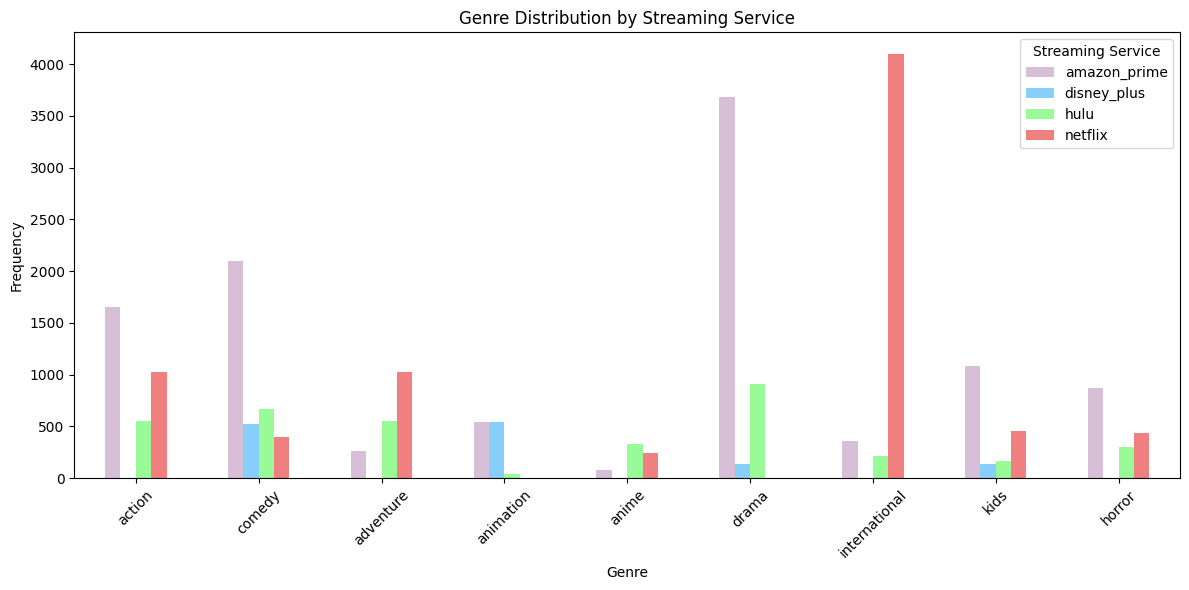

In [8]:
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

#frequency of each genre for each streaming service
genre_table = streaming_full.groupby("channel_streaming")[genres].sum()
genre_df = pd.DataFrame(genre_table)
genre_df = genre_df.T

#create grouped bar chart of genre by streaming service 
genre_df.plot(kind="bar", figsize=(12, 6), color = ["thistle", "lightskyblue", "palegreen", "lightcoral"])
plt.xlabel("Genre")
plt.ylabel("Frequency")
plt.title("Genre Distribution by Streaming Service")
plt.legend(title="Streaming Service")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** The grouped bar chart indicates that Disney Plus doesn't have any obervations for action, adventure, anime, international, nor horror genres. Similarly, Netflix doesn't have any observations for the animation nor drama genres. Both Amazon Prime and Hulu have observations for each genre. There are two clear frequency outliers, which are Amazon Prime in the drama genre and Netflix in the international genre. Both of those bars have unusually high frequency counts.

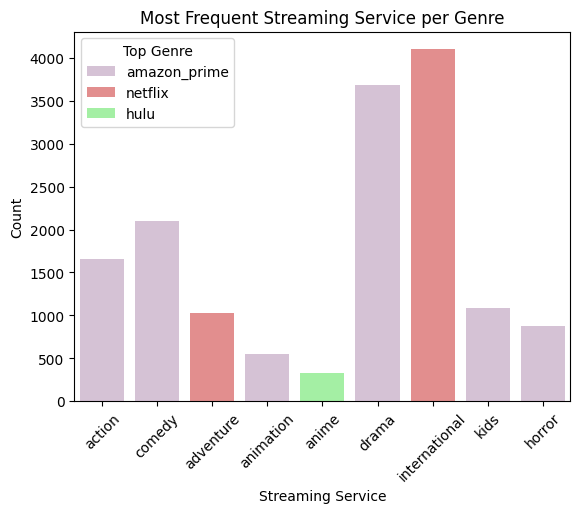

In [9]:
#max frequency of streaming serivce and max genre
top_genres = genre_df.idxmax(axis=1)
top_counts = genre_df.max(axis=1)

#subset data to streaming services with the highest frequency per genre
top_df = pd.DataFrame({
    "Streaming Service": top_genres.index,
    "Top Genre": top_genres.values,
    "Count": top_counts.values})

#create color pallete to match other graphs
palette = {
    "disney_plus": "lightskyblue",
    "hulu": "palegreen", 
    "amazon_prime": "thistle",
    "netflix": "lightcoral"}

#create bar chart of Most Frequent Streaming Service per Genre
sns.barplot(
    data=top_df,
    x="Streaming Service",
    y="Count",
    hue="Top Genre", 
    palette = palette)

plt.title("Most Frequent Streaming Service per Genre")
plt.xticks(rotation=45)
plt.show()

**Interpretation:** Amazon Prime is the streaming service with the highest frequency in six og the genres (action, comedy, animation, drama, kids, and horror). Netflix has the highest frequency for the adventure and international genres. Hulu has the highest frequency for anime. Disney Plus doesn't have the highest frequency for any of the genres. 

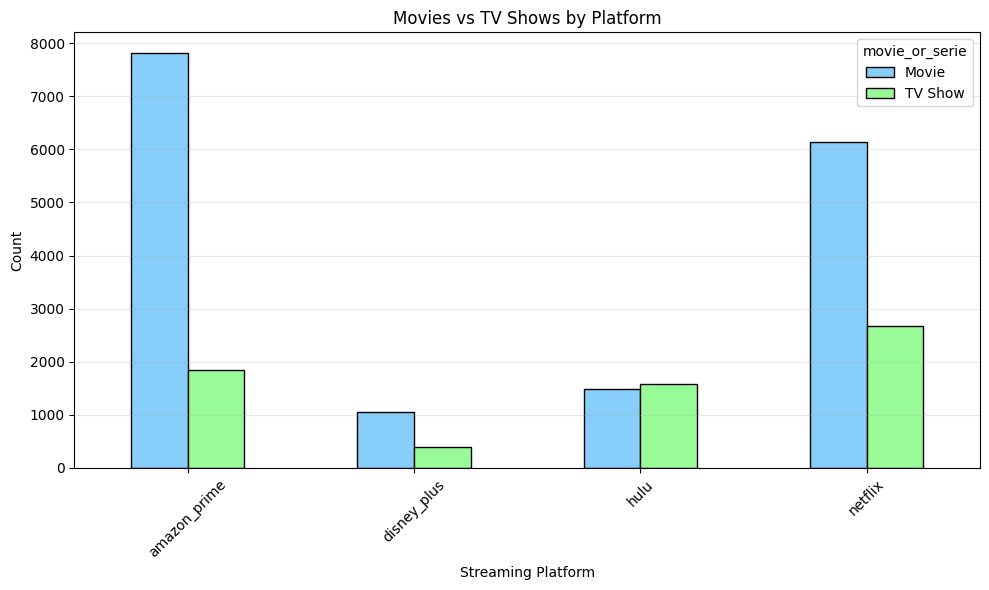

In [10]:
# movies vs tv shows by platform
counts = streaming_full.groupby(["channel_streaming", "movie_or_serie"]).size().unstack()
ax = counts.plot(kind="bar", figsize=(10,6), color=["lightskyblue", "palegreen"], edgecolor='black')
plt.xlabel("Streaming Platform")
plt.ylabel("Count")
plt.title("Movies vs TV Shows by Platform")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**: Amazon Prime, Disney+, and Netflix all have more movies than TV shows. They each have more than two times the number of movies than TV shows. Hulu is the only streaming service with more TV shows than movies. 

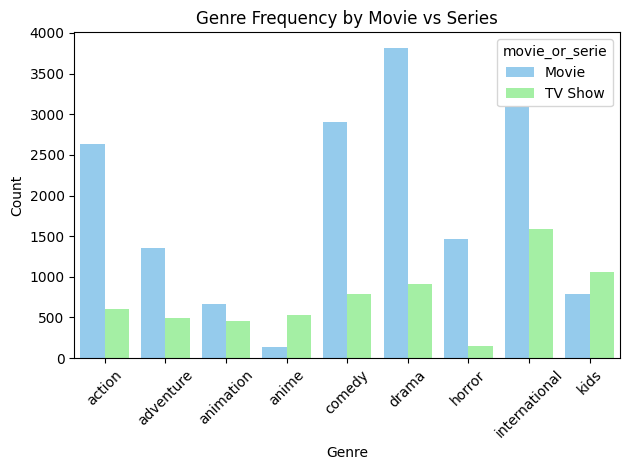

In [11]:
#format data to long format
long_df = streaming_full.melt(
    id_vars=["movie_or_serie"],
    value_vars=genres,
    var_name="Genre",
    value_name="Has_Genre")

#subset only observations that are 1 (binary variables)
long_df = long_df[long_df["Has_Genre"] == 1]

#create df of frequencies
count_df = (
    long_df
    .groupby(["Genre", "movie_or_serie"])
    .size()
    .reset_index(name="Count"))

#create color pallete to match other graphs
palette = {
    "Movie": "lightskyblue",
    "TV Show": "palegreen"}

#create grouped bar chart of movie or series by genre
sns.barplot(
    data=count_df,
    x="Genre",
    y="Count",
    hue="movie_or_serie",
    palette=palette)

plt.xticks(rotation=45)
plt.title("Genre Frequency by Movie vs Series")
plt.tight_layout()
plt.show()

**Interpretation**: The anime and kids genres have more TV shows than movies. All the other genres have more movies than TV shows. 

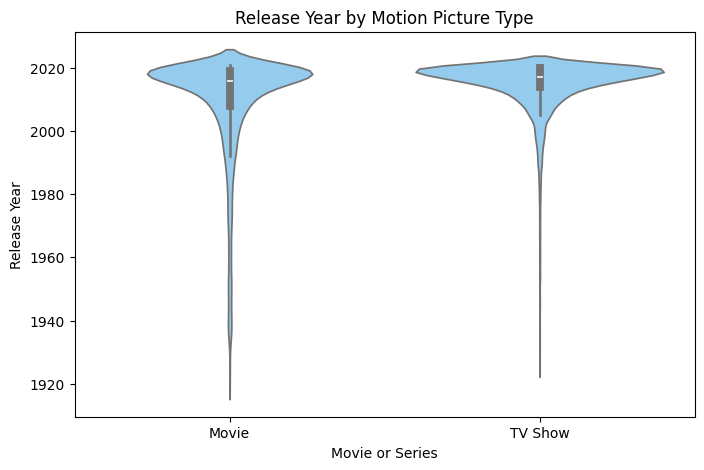

Group means:
movie_or_serie
Movie      2009.224562
TV Show    2014.823845
Name: release_year, dtype: float64


In [12]:
#Side by side violin  plots for release year
plt.figure(figsize=(8, 5))
sns.violinplot(data=streaming_full, x='movie_or_serie', y='release_year', color="lightskyblue")
plt.title('Release Year by Motion Picture Type')
plt.ylabel('Release Year')
plt.xlabel("Movie or Series")
plt.show()

#average release year for movies vs series
means = streaming_full.groupby('movie_or_serie')['release_year'].mean()
print("Group means:")
print(means)

**Interpretation**: The distribution of release year is similar for both movies and series. They are both left skewed. Movies have a more variable spread with a range of 1920-2021 and a mean release date of 2009. TV shows have a slightly smaller range from 1925-2021, with the majority of the observations having a more recent release year, the average being 2015.

### **Documentation**

The first research question explores the relationship between genre and streaming platform. Thus, we created a grouped bar chart of genre distribution by streaming service to visualize the frequencies of each streaming service for each genre. Then, we explored which streaming services had the highest frequency for each of the genres using a bar chart. These graphs allowed us to infer that there appears to be a relationship between genre and streaming platform due to the uneven distributions. The second research question explored the relationship between streaming services and movies or series. So, we created a grouped bar chart with the frequencies of movies and TV shows for each streaming service. This allowed us to visualize the distribution of movie or series across the different platforms. From our graphs we determined that there appears to be a relationship between movie or series and streaming platform due to the unequal distributions. The third research question explores how movies and series are related to the other variables in the dataset. Consequently, we created a grouped bar chart to show the distribution of movie or series for each of the genres in the dataset. Finally, we created side-by-side violin plots to depict the distribution of movie or series by release year. Similarly, we determined that movies and TV shows seem to have unique identifers due to the unequal distributions across the different platform and genres.

### **Reporting and Interpretation**

done throughout the section 

## **Comparative Analysis**

In [13]:
#NOTE: originally I created these for the descriptive stats, but I think they fit better in this section, feel free to use them if you want here
#frequency of each genre for each streaming service
genres = ['action', 'comedy', 'adventure', 'animation','anime', 'drama', 'international', 'kids', 'horror']

genre_table = streaming_full.groupby("channel_streaming")[genres].sum()

print("Genre Frequency per Streaming Service:")
print(genre_table)

#frequency of each movie or tv show for each streaming service
print("\nMovie or Streaming distributiton for Streaming Service:")
proportions_movie_show = (streaming_full.groupby("channel_streaming")["movie_or_serie"].value_counts(normalize=True).unstack(fill_value=0))
print(proportions_movie_show)

Genre Frequency per Streaming Service:
                   action  comedy  adventure  animation  anime  drama  \
channel_streaming                                                       
amazon_prime         1657    2099        259        547     80   3687   
disney_plus             0     526          0        542      4    134   
hulu                  555     667        556         37    329    907   
netflix              1027     399       1027          0    247      0   

                   international  kids  horror  
channel_streaming                               
amazon_prime                 355  1085     875  
disney_plus                    0   141       0  
hulu                         216   162     304  
netflix                     4103   451     432  

Movie or Streaming distributiton for Streaming Service:
movie_or_serie        Movie   TV Show
channel_streaming                    
amazon_prime       0.808233  0.191767
disney_plus        0.725517  0.274483
hulu               

### **Documentation**

### **Reporting and Interpretation**

## **Multivariate Analysis**

In [43]:
# 1. Are there significant differences in genre distribution across streaming platforms?
print("RQ1 - PIVOT TABLE: Genre Counts by Platform and Content Type")
print("=" * 60)
for content_type in ["Movie", "TV Show"]:
    subset = streaming_full[streaming_full["movie_or_serie"] == content_type]
    pivot = subset.groupby("channel_streaming")[genres].sum()
    print(f"\n--- {content_type}s ---")
    print(pivot)

RQ1 - PIVOT TABLE: Genre Counts by Platform and Content Type

--- Movies ---
                   action  comedy  adventure  animation  anime  drama  \
channel_streaming                                                       
amazon_prime         1502    1821        230        279     29   3206   
disney_plus             0     407          0        381      0    121   
hulu                  273     337        260          5     35    489   
netflix               859     343        859          0     71      0   

                   international  kids  horror  
channel_streaming                               
amazon_prime                 284   679     845  
disney_plus                    0    39       0  
hulu                          55    67     258  
netflix                     2752     0     357  

--- TV Shows ---
                   action  comedy  adventure  animation  anime  drama  \
channel_streaming                                                       
amazon_prime          155 

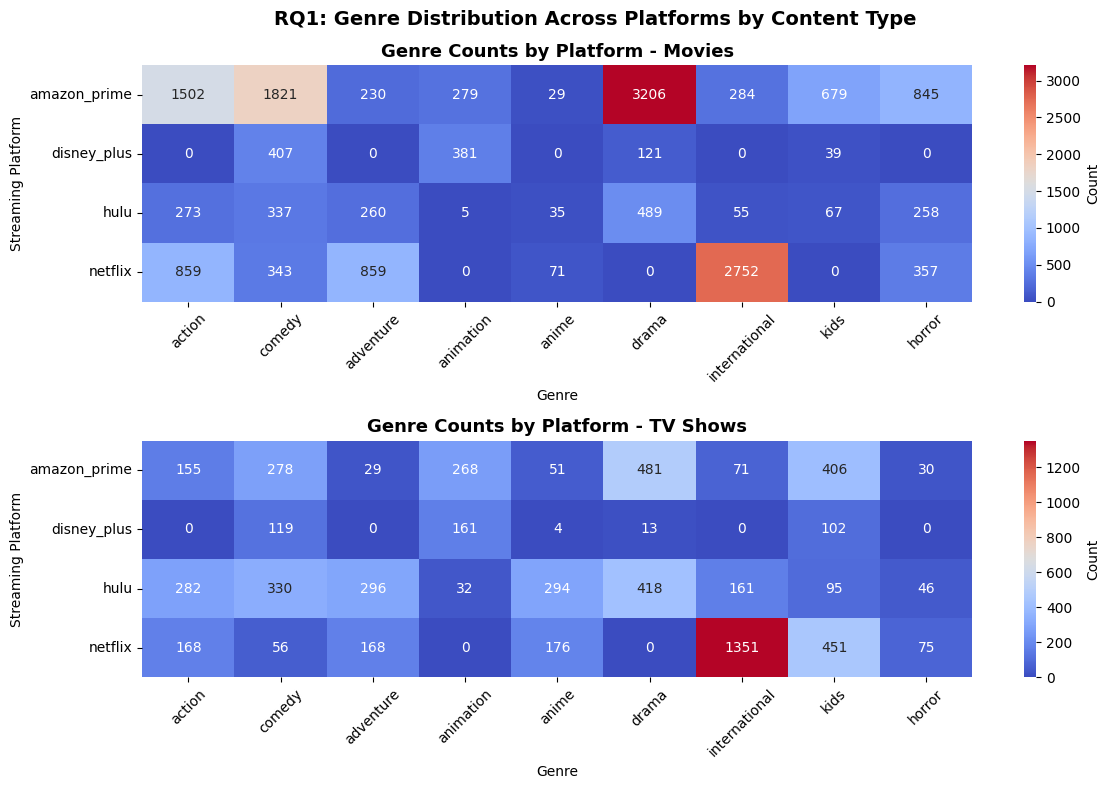

In [ ]:
# Heatmap: genre x platform, split by content type
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, content_type in zip(axes, ["Movie", "TV Show"]):
    subset = streaming_full[streaming_full["movie_or_serie"] == content_type]
    pivot = subset.groupby("channel_streaming")[genres].sum()
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm", ax=ax, cbar_kws={"label": "Count"})
    ax.set_title(f"Genre Counts by Platform - {content_type}s", fontsize=13, fontweight="bold")
    ax.set_xlabel("Genre")
    ax.set_ylabel("Streaming Platform")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("RQ1: Genre Distribution Across Platforms by Content Type", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [41]:
# 2. Is there a difference between the platforms in their balance between movies and television shows?
print("RQ2 - CROSS-TABULATION: Content Type by Platform")
print("=" * 60)
ct = pd.crosstab(
    streaming_full["channel_streaming"],
    streaming_full["movie_or_serie"],
    margins=True,
    margins_name="Total"
)
print(ct)

print("\nCOLUMN PROPORTIONS: Content Type within each Platform")
print("=" * 60)
ct_prop = (
    pd.crosstab(
        streaming_full["channel_streaming"],
        streaming_full["movie_or_serie"],
        normalize="index"
    ) * 100
)
print(ct_prop.round(2))

RQ2 - CROSS-TABULATION: Content Type by Platform
movie_or_serie     Movie  TV Show  Total
channel_streaming                       
amazon_prime        7814     1854   9668
disney_plus         1052      398   1450
hulu                1484     1589   3073
netflix             6131     2676   8807
Total              16481     6517  22998

COLUMN PROPORTIONS: Content Type within each Platform
movie_or_serie     Movie  TV Show
channel_streaming                
amazon_prime       80.82    19.18
disney_plus        72.55    27.45
hulu               48.29    51.71
netflix            69.62    30.38


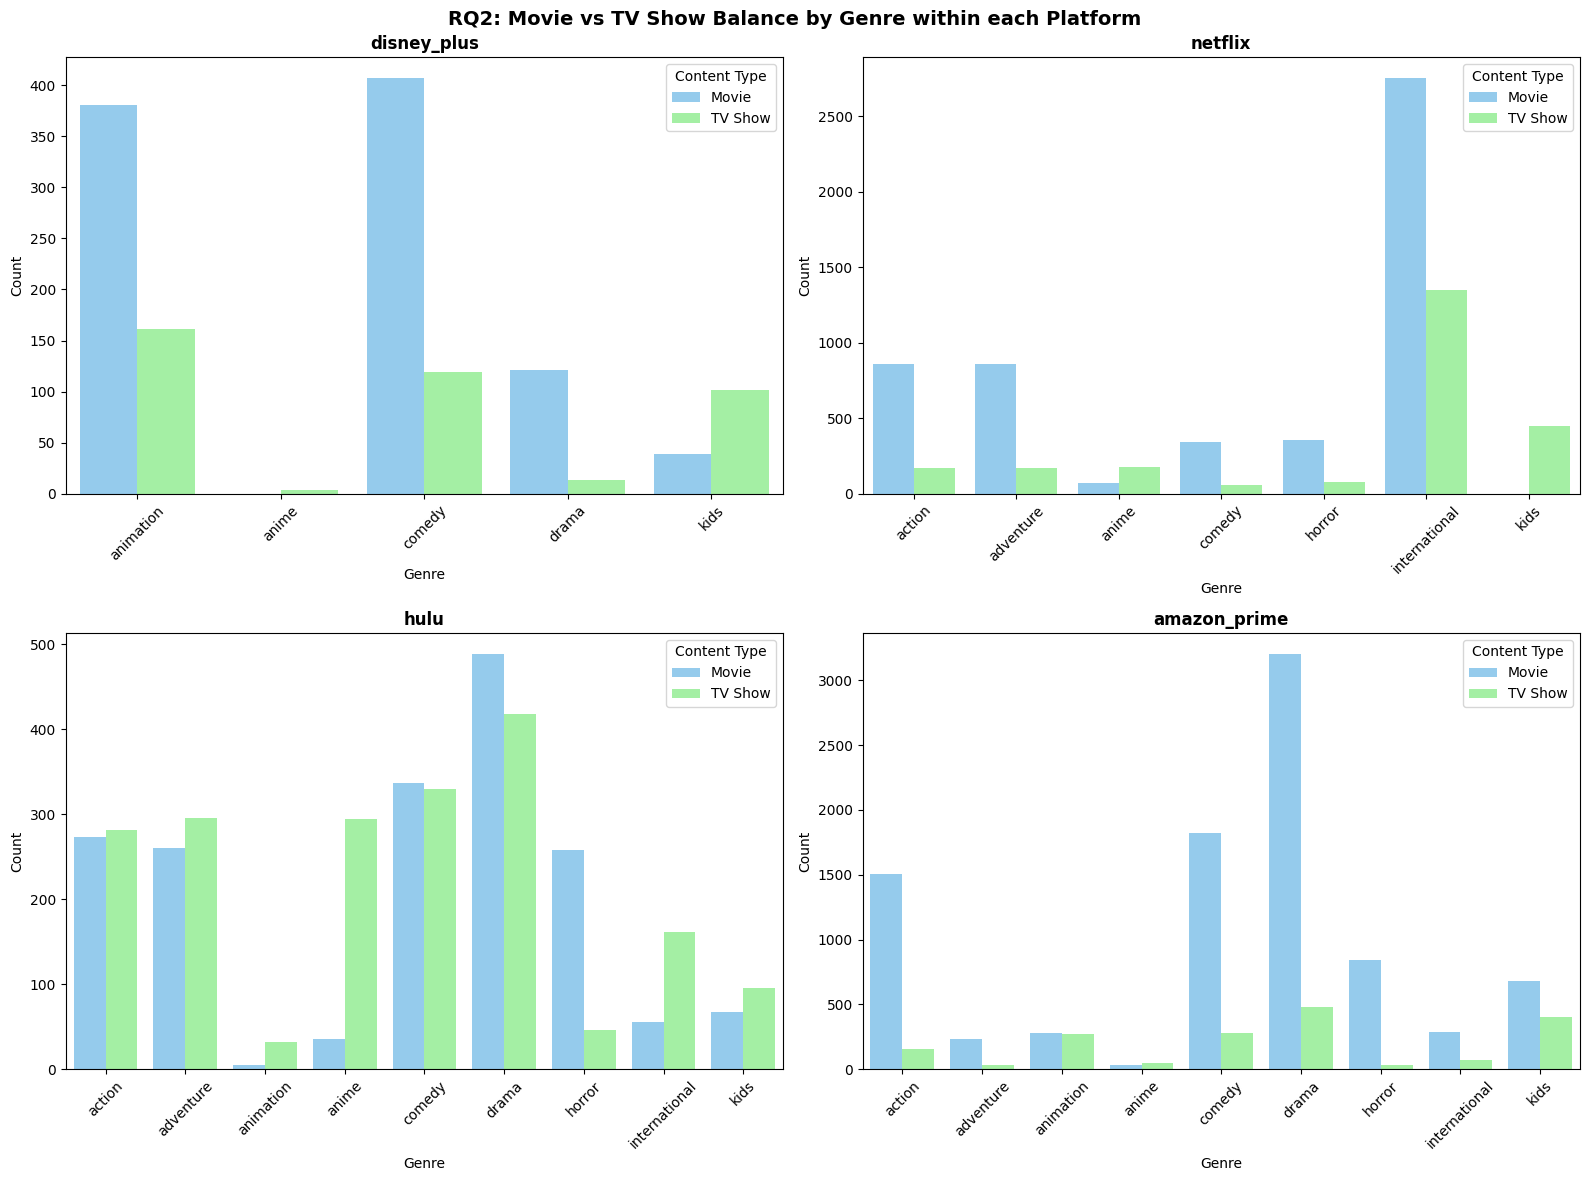

In [42]:
# grouped bar chart: genre x content type for each platform
df = streaming_full.melt(
    id_vars=["channel_streaming", "movie_or_serie"],
    value_vars=genres,
    var_name="Genre",
    value_name="Has_Genre"
)
df = df[df["Has_Genre"] == 1]

count_df = (
    df.groupby(["channel_streaming", "Genre", "movie_or_serie"]).size().reset_index(name="Count")
)

platforms = streaming_full["channel_streaming"].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, platform in zip(axes, platforms):
    subset = count_df[count_df["channel_streaming"] == platform]
    sns.barplot(data=subset, x="Genre", y="Count", hue="movie_or_serie", palette={"Movie": "lightskyblue", "TV Show": "palegreen"}, ax=ax)
    ax.set_title(f"{platform}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Genre")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Content Type")

plt.suptitle("RQ2: Movie vs TV Show Balance by Genre within each Platform", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [58]:
# 3. Can observations be accurately classified as "Movie" or "TV Show" by their known attributes?
print("RQ3 - PIVOT TABLE: Mean Release Year by Platform and Content Type")
print("=" * 60)
pivot_year = streaming_full.pivot_table(
    values="release_year", index="channel_streaming", columns="movie_or_serie", aggfunc="mean"
)
print(pivot_year.round(2))

RQ3 - PIVOT TABLE: Mean Release Year by Platform and Content Type
movie_or_serie       Movie  TV Show
channel_streaming                  
amazon_prime       2006.87  2014.55
disney_plus        1999.23  2013.30
hulu               2012.61  2012.53
netflix            2013.12  2016.61


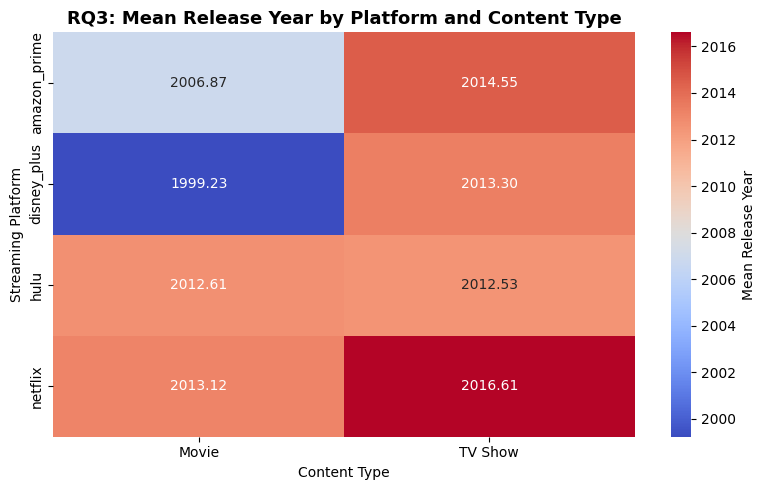

In [59]:
# Heatmaps: genre x platform, split by content type
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_year, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Mean Release Year"})
plt.title("RQ3: Mean Release Year by Platform and Content Type", fontsize=13, fontweight="bold")
plt.xlabel("Content Type")
plt.ylabel("Streaming Platform")
plt.tight_layout()
plt.show()

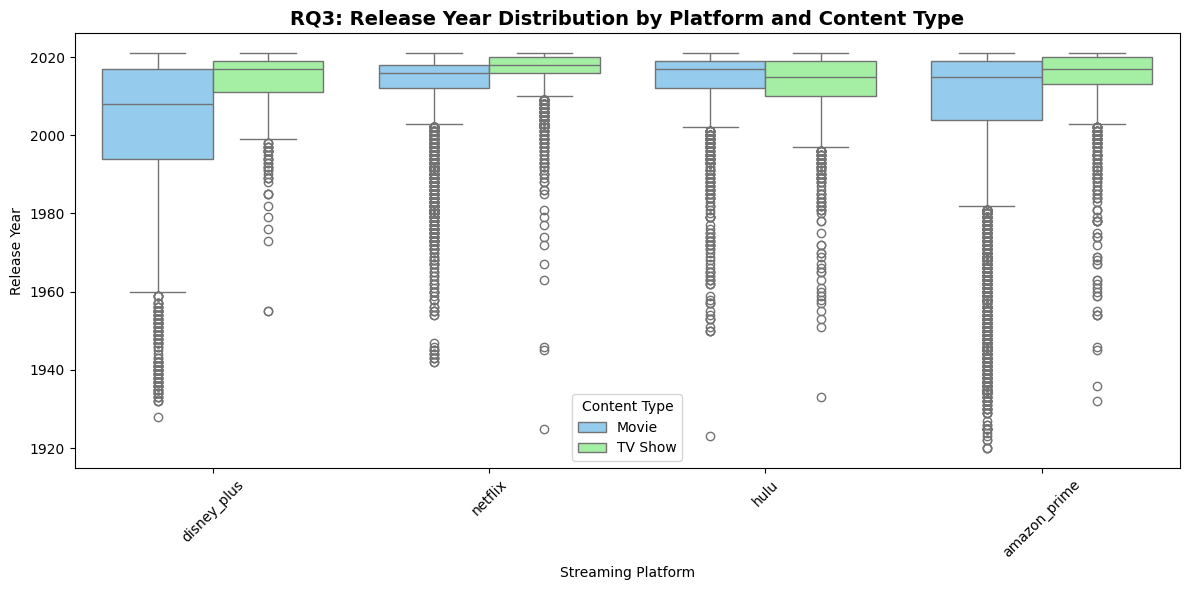

In [61]:
# Boxplot: release year x content type x platform 
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=streaming_full, x="channel_streaming", y="release_year", hue="movie_or_serie", palette={"Movie": "lightskyblue", "TV Show": "palegreen"} 
)
plt.title("RQ3: Release Year Distribution by Platform and Content Type", fontsize=14, fontweight="bold")
plt.xlabel("Streaming Platform")
plt.ylabel("Release Year")
plt.legend(title="Content Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Documentation**

### **Reporting and Interpretation**

## **Synthesis**

### **Documentation**

### **Reporting and Interpretation**

## **Reflection**

### **Documentation**

### **Reporting and Interpretation**